# Deep Species Distribution Models

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np

For SDMs we will use a custom loss build for Presence-Only data. What this does is contrast the predicted intensity of a species presence $j$ in site $i$ against all other intensities in the batch $B$. This looks as follows.
$$L(y,\lambda)=\sum_{ij} y_{ij} \cdot \frac{\lambda_{ij}}{\sum_{b \in B} \lambda_{bj}}$$
Where $\lambda$ is obtained from the raw output of a Neural Network as: $\lambda = e^{f_{\theta}}$

In [29]:
class DeepMaxEntLoss(nn.Module):
    def __init__(self, eps=1e-8, pos_weight=None):
        super().__init__()
        self.eps = eps
        self.register_buffer("pos_weight", pos_weight if pos_weight is not None else None)

    def forward(self, input, target):
        # input:  (B,C)
        # target: (B,C) multi-hot

        w = 1.0
        if self.pos_weight is not None:
            w = self.pos_weight.unsqueeze(0)  # (1,C)

        # Only count positive entries in the normalization
        weighted_target = target * w

        logp = input.log_softmax(dim=0)  # softmax over batch, per class
        loss_num = -(weighted_target * logp).sum()
        loss_den = weighted_target.sum().clamp_min(self.eps)
        return loss_num / loss_den

class MLP(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int, hidden_layers: int):
        super().__init__()

        # --- backbone (feature extractor) --
        self.fc1 = nn.Linear(input_size, hidden_size)

        # residual hidden blocks: Linear -> ReLU -> add residual
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(hidden_size, hidden_size) for _ in range(hidden_layers)]
        )

        # expose a handle called "feature_extractor" so code outside can freeze it
        # (just keep references to same modules)
        self.feature_extractor = nn.ModuleDict({
            "fc1": self.fc1,
            "hidden_layers": self.hidden_layers
        })

        # --- head (output layer) ---
        # keep bias=False like your original
        self.output_layer = nn.Linear(hidden_size, output_size, bias=False)


    def get_features(self, x: torch.Tensor) -> torch.Tensor:
        """Compute backbone features (before final linear head)."""
        x = F.relu(self.fc1(x))
        for layer in self.hidden_layers:
            h = F.relu(layer(x))
            x = x + h              # residual connection
        return x                   # feature vector z

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.get_features(x)
        logits = self.output_layer(z)  # logits; apply sigmoid outside if needed
        return logits


In [30]:

po_path = 'data/SWItrain_po.csv'
pa_path = 'data/SWItest_pa.csv'
env_path = 'data/SWItest_env.csv'

index_col = ["x", "y"]  # columns that identify spatial locations

# Presence-only (PO) records
df_po = pd.read_csv(po_path)

# PA labels + environmental covariates
df_pa = pd.read_csv(pa_path)
df_env = pd.read_csv(env_path)

# covariates from 5th col onward in env
covariates = df_env.columns[4:].tolist()

# Species 
species = sorted(df_po["spid"].unique().tolist()) 


# Y_PA is species and covariates
Y_pa = df_pa[species].copy()
X_pa = df_env[covariates].copy()

# --- Build Y_po: pivot to multi-label per (x, y)
Y_po = (
    df_po.pivot_table(index=index_col, columns="spid", aggfunc="size", fill_value=0)
        .reset_index()
)


# --- X_po: mean covariates at (x, y)
X_po = (
    df_po.groupby(index_col)[covariates]
        .mean()
        .reset_index()
)

# Align PO by (x,y) join
XY_po = pd.merge(X_po, Y_po, on=index_col, how="inner")


# Split X and Y for PO
X_po = XY_po[covariates].copy()
Y_po = XY_po[species].copy()

# Clip PA values to 0,1 (as PA labels should be binary, but may have some noise)
Y_pa[species] = np.clip(Y_pa[species], 0, 1)

# scale covariates (fit on PA, apply to both)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_pa = scaler.fit_transform(X_pa)
X_po = scaler.transform(X_po)


Epoch   0 | mean AUC 0.490  (random init)
Epoch   5 | loss 5.2649 | mean AUC 0.803
Epoch  10 | loss 5.1255 | mean AUC 0.831
Epoch  15 | loss 5.0816 | mean AUC 0.837
Epoch  20 | loss 5.0606 | mean AUC 0.839


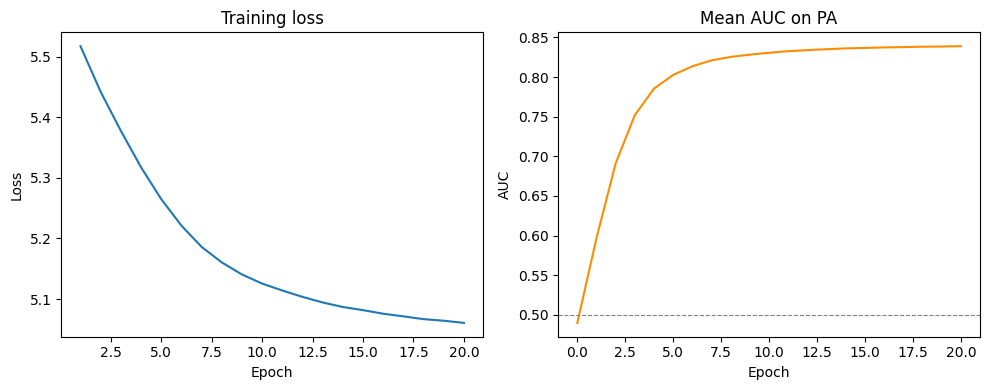

In [42]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# ── 1. Hyper-parameters ───────────────────────────────────────────────────────
N_FEATURES   = len(covariates)
N_SPECIES    = len(species)
N_EPOCHS     = 20
LR           = 1e-4
BATCH_SIZE   = 256
WEIGHT_DECAY = 3e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



# ── 2. DataFrames → tensors ───────────────────────────────────────────────────
X_po_t = torch.tensor(X_po, dtype=torch.float32)
Y_po_t = torch.tensor(Y_po.values, dtype=torch.float32)
X_pa_t = torch.tensor(X_pa, dtype=torch.float32).to(device)
Y_pa_np = Y_pa.values  # kept as numpy for roc_auc_score

po_loader = DataLoader(TensorDataset(X_po_t, Y_po_t), batch_size=BATCH_SIZE, shuffle=True)



# ── 3. Model, loss, optimiser ─────────────────────────────────────────────────
model     = MLP(N_FEATURES, hidden_size=100, output_size=N_SPECIES, hidden_layers=2).to(device)
criterion = DeepMaxEntLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ── 4. Evaluation helper ──────────────────────────────────────────────────────
def evaluate(model):
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_pa_t)).cpu().numpy()
    return [
        roc_auc_score(Y_pa_np[:, s], probs[:, s])
        for s in range(N_SPECIES) if Y_pa_np[:, s].sum() > 0
    ]

# ── 5. Training loop (epoch 0 = before any update) ───────────────────────────
history = {"loss": [None], "mean_auc": [sum(evaluate(model)) / N_SPECIES]}
print(f"Epoch   0 | mean AUC {history['mean_auc'][0]:.3f}  (random init)")

for epoch in range(1, N_EPOCHS + 1):

    model.train()
    losses = []
    for xb, yb in po_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    aucs = evaluate(model)
    history["loss"].append(sum(losses) / len(losses))
    history["mean_auc"].append(sum(aucs) / len(aucs))

    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d} | loss {history['loss'][-1]:.4f} | mean AUC {history['mean_auc'][-1]:.3f}")

# ── 6. Plot ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(range(1, N_EPOCHS + 1), history["loss"][1:])
ax1.set(title="Training loss", xlabel="Epoch", ylabel="Loss")

ax2.plot(history["mean_auc"], color="darkorange")
ax2.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax2.set(title="Mean AUC on PA", xlabel="Epoch", ylabel="AUC")

plt.tight_layout()
plt.show()

# Building Maps with Our Model

One of the main objectives of training an SDM is to build a map for the species range across a whole region of interest. What we would do now is to make a map for Switzerland where we see the relative intensity of each species using the full raster of covariates. 

It is important to note that this is a relative intensity.

In [44]:
X_map

tensor([[   255.,    255.,    255.,  ..., -32768., -32768., -32768.],
        [   255.,    255.,    255.,  ..., -32768., -32768., -32768.],
        [   255.,    255.,    255.,  ..., -32768., -32768., -32768.],
        ...,
        [   255.,    255.,    255.,  ..., -32768., -32768., -32768.],
        [   255.,    255.,    255.,  ..., -32768., -32768., -32768.],
        [   255.,    255.,    255.,  ..., -32768., -32768., -32768.]])

In [ ]:
import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

tiff_dir = Path("data/rasters")  # adjust if needed
border   = gpd.read_file("data/swi.gpkg")

# ── 1. Load rasters in covariate order ───────────────────────────────────────
rasters = {Path(f).stem: rasterio.open(f) for f in sorted(tiff_dir.glob("*.tif"))}
ref     = next(iter(rasters.values()))          # use first raster for shape/transform
height, width = ref.height, ref.width

# Stack covariates in the same order as the model was trained
stack = np.stack([rasters[c].read(1) for c in covariates], axis=-1)  # (H, W, F)
nodata_mask = np.isnan(stack).any(axis=-1)
# use border geometry to mask out non-land areas (if needed)
from rasterio.features import geometry_mask
land_mask = geometry_mask(border.geometry, transform=ref.transform, invert=True, out_shape=(height, width))
nodata_mask = nodata_mask | ~land_mask


# ── 2. Predict ────────────────────────────────────────────────────────────────
flat  = stack.reshape(-1, len(covariates))
X_map = torch.tensor(flat, dtype=torch.float32).to(device)
# scale covariates using same scaler as training
X_map = torch.tensor(scaler.transform(X_map.cpu()), dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    raw_intensities = torch.exp(model(X_map)).cpu().numpy()  

intensity_maps = raw_intensities.reshape(height, width, len(species))  
intensity_maps[nodata_mask] = np.nan
# normalize each species map to [0,1] for relative intensity
intensity_maps = intensity_maps / np.nansum(intensity_maps, axis=(0,1), keepdims=True)

# ── 3. Plot one map per species ───────────────────────────────────────────────
ncols = 4
nrows = int(np.ceil(len(species) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))

extent = [ref.bounds.left, ref.bounds.right, ref.bounds.bottom, ref.bounds.top]

for src in rasters.values(): src.close()

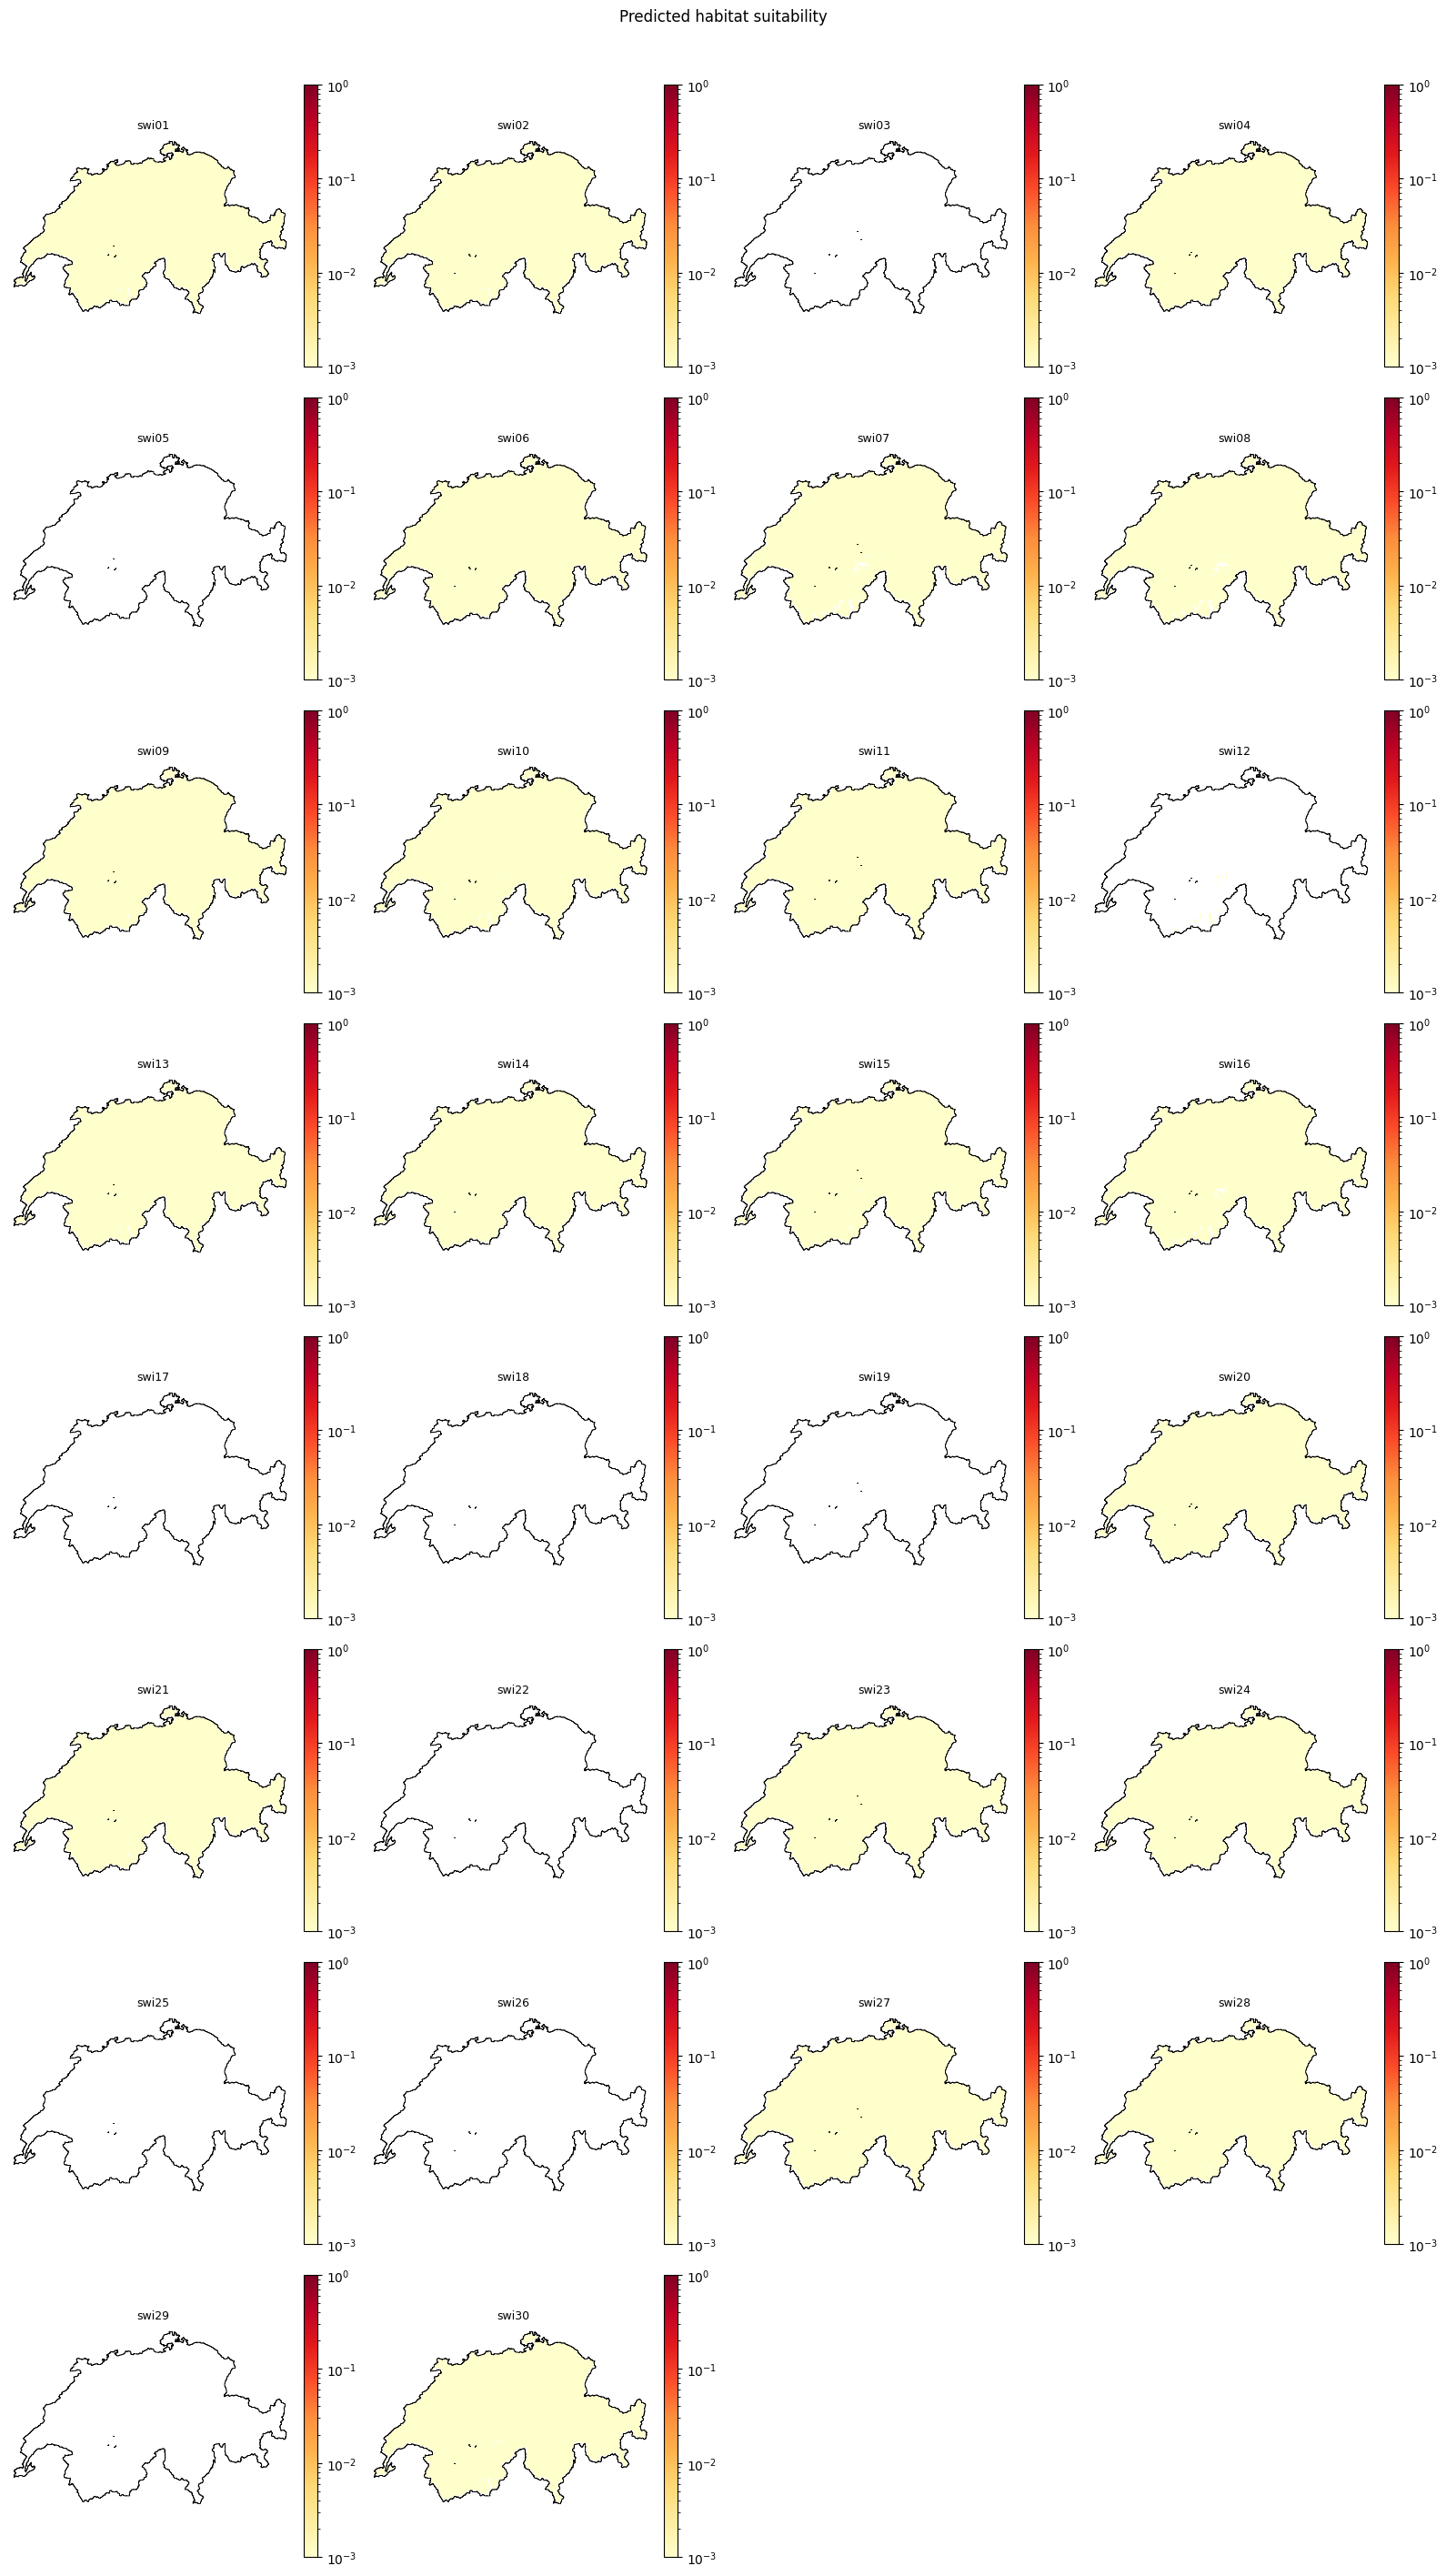

In [74]:
# LogNorm for better color scaling of suitability
from matplotlib.colors import LogNorm

ncols = 4
nrows = int(np.ceil(len(species) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))

for ax, sp, i in zip(axes.flat, species, range(len(species))):
    im = ax.imshow(intensity_maps[:, :, i], origin="upper", extent=extent,
                   cmap="YlOrRd", norm=LogNorm(vmin=1e-3, vmax=1))
    border.boundary.plot(ax=ax, linewidth=0.6, color="black")
    ax.set_title(sp, fontsize=9)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

for ax in axes.flat[len(species):]:
    ax.axis("off")

plt.suptitle("Predicted habitat suitability", y=1.01)
plt.tight_layout()
plt.show()

for src in rasters.values(): src.close()

In [ ]:
# nansum for species 1
species1 = intensity_maps[:,:,1]
total_suitability = np.nansum(species1)
print(f"Total suitability for {species[1]}: {total_suitability:.2f}")

Total suitability for swi02: 1.01
